# Sparsity study 

TODO:
- fix bootstrap
- run boostrap
- check if we want to re-run algo after finding the sparsity matrix (instead of sparsifying as epochs go by), maybe order 2
- add TCTC section and study the temporal attention matrices
- check with a sparsity with shift_cs? maybe not necessary but interesting

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
import torch
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader
import importlib
import sys
sys.path.append('/Users/cyrilgarcia/notebooks/tsnn/')

import tsnn

from tsnn.generators import generators
from tsnn import tstorch
from tsnn.benchmarks import benchmark_comparison, ml_benchmarks, torch_benchmarks
from tsnn import utils
from tsnn.tstorch import transformers
import torch.nn.functional as F
import math
from typing import Optional

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from torch import nn
from tqdm import tqdm
device = 'mps'


plt.style.use('ggplot')

In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    T: int = 5000
    n_ts: int = 10
    n_f: int = 20
    pct_zero_corr: float = 0.5
    split_conditional: float = 0.0
    split_shift: float = 1.0
    split_seasonal: float = 0.0
    split_cs: float = 0.0
    split_cs_shift: float = 0.0
    low_corr: float = 0.05
    high_corr: float = 0.1

In [3]:
z = generators.Generator(Config.T, Config.n_ts, Config.n_f)

In [4]:
%%time
z.generate_dataset(pct_zero_corr = Config.pct_zero_corr,
                  split_conditional = Config.split_conditional,
                  split_shift = Config.split_shift,
                  split_seasonal = Config.split_seasonal,
                  split_cs=Config.split_cs,
                  split_cs_shift=Config.split_cs_shift,
                  low_corr=Config.low_corr, 
                  high_corr=Config.high_corr)

CPU times: user 24.6 ms, sys: 8.23 ms, total: 32.8 ms
Wall time: 74.1 ms


In [5]:
z.get_dataloader(n_rolling=10)

In [6]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def causal_mask_radius(b, h, q_idx, kv_idx):
    return (q_idx >= kv_idx) & (q_idx <= kv_idx+1)

def plot_mask(mask_fn, seq_len=20, title=None, device="cpu"):
    """
    Plot a binary attention mask defined by mask_fn(b,h,q_idx,kv_idx)
    as a (seq_len x seq_len) matrix.
    """
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device) 
    h = torch.zeros(1, device=device)

    mask = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])
    mask = mask.float().cpu()

    return pd.DataFrame(mask).style.background_gradient(axis=None).format(precision=0)

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool


In [7]:
mask_fn = causal_mask
plot_mask(mask_fn, seq_len=5)

,0,1,2,3,4
0,1,0,0,0,0
1,1,1,0,0,0
2,1,1,1,0,0
3,1,1,1,1,0
4,1,1,1,1,1


In [8]:
mask_fn = causal_mask_radius
plot_mask(mask_fn, seq_len=5)

,0,1,2,3,4
0,1,0,0,0,0
1,1,1,0,0,0
2,0,1,1,0,0
3,0,0,1,1,0
4,0,0,0,1,1


In [9]:
from tsnn.tstorch import models

In [10]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmarkRolling(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

In [11]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

mask = causal_mask
mask = build_attention_mask(mask, 10, device=device)

In [12]:
def keep_topk_per_row(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out

In [13]:
def keep_by_max_value(x, frac=0.1):
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    out = (x >= threshold).to(x.dtype)
    return out

## List of models

Tried and shown below, I only use a TC model (time + cross sectionnal) and 1 head to make everything simple. I look at a noisy setup of the temporal shift effect.
- Full attention matrix
- Top k coefficients per row of the attention matrix
- Including gated coefficients on each matrix diagonal to get the best MSE while maximizing the sparsity of the attention matrix
- After studying the attention matrix found by the full model, decided to use a method based on the max value of each row to clean the matrix (intuitive since this is a probability space)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:58<00:00,  2.92s/it]


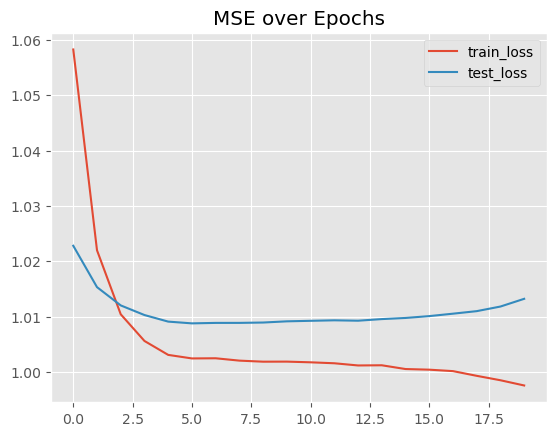

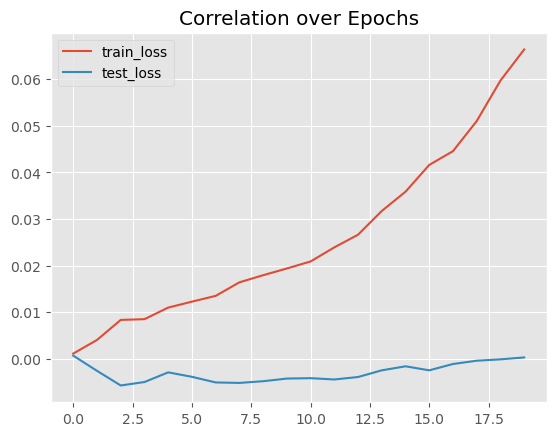

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:08<00:00,  3.40s/it]


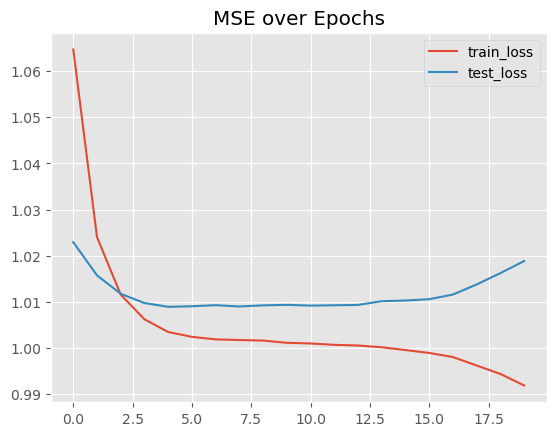

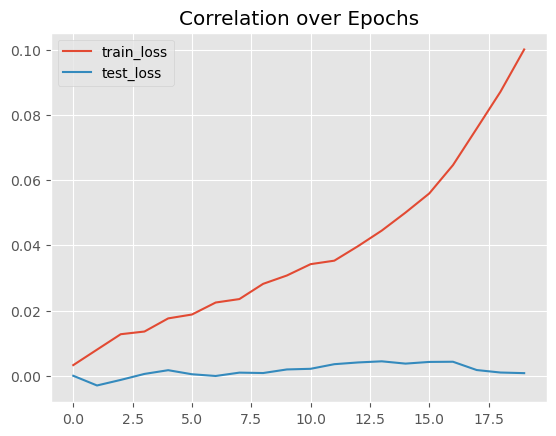

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:09<00:00,  3.49s/it]


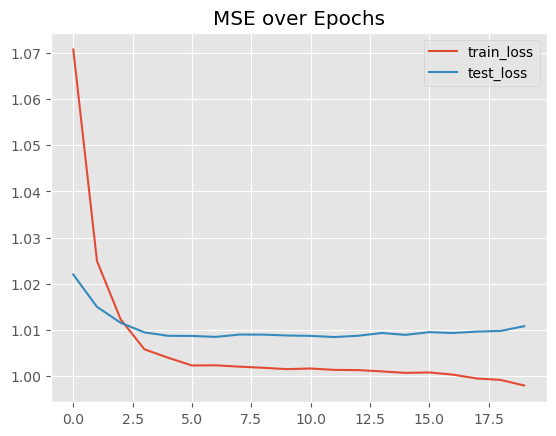

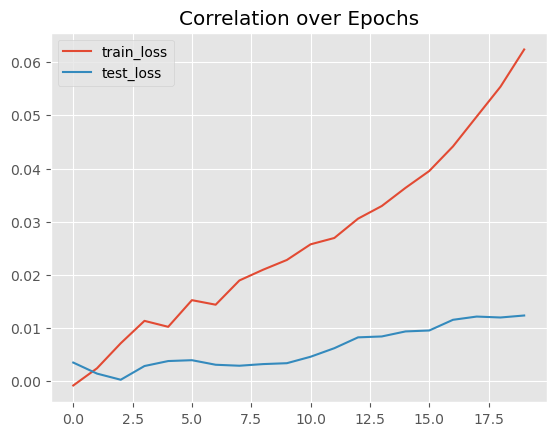

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:07<00:00,  3.39s/it]


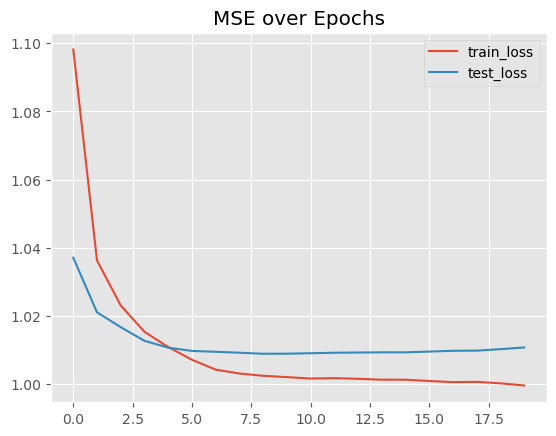

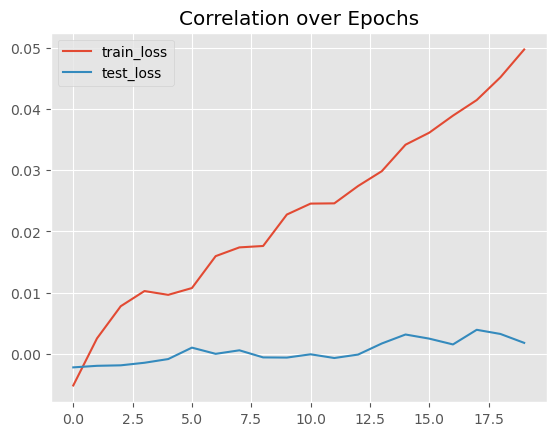

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:08<00:00,  3.40s/it]


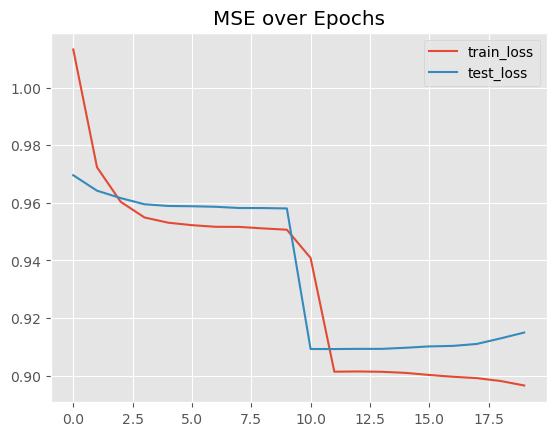

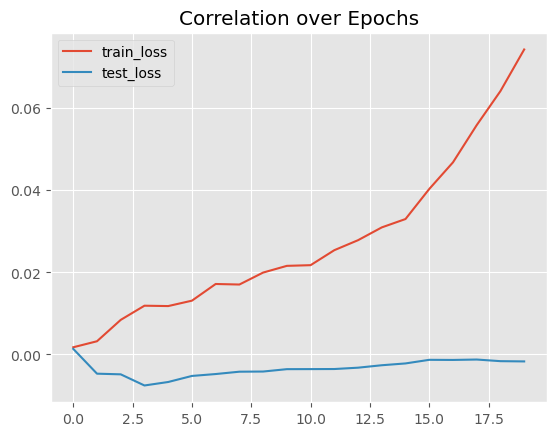

Gated coefficients for sparse model:
Layer 0: [0.20048442 0.20154054 0.         0.         0.         0.
 0.19967967 0.         0.19917491 0.19912043]


,true,optimal,shift,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.027,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.027,1.000,nan,nan,nan,nan,nan,nan,nan,nan
lasso,0.045,-0.003,-0.003,nan,nan,nan,nan,nan,nan,nan
boosting,0.151,0.005,0.005,0.220,nan,nan,nan,nan,nan,nan
mlp,0.152,0.003,0.003,0.193,0.687,nan,nan,nan,nan,nan
full_attention,0.085,0.223,0.223,0.022,0.071,0.065,nan,nan,nan,nan
deterministic_sparse,0.121,0.336,0.336,0.003,0.048,0.044,0.256,nan,nan,nan
top_k_sparse,0.083,0.421,0.421,0.059,0.061,0.064,0.354,0.371,nan,nan
max_sparse,0.071,0.422,0.422,0.000,0.050,0.039,0.378,0.355,0.487,nan
dynamic_sparse,0.092,0.072,0.072,0.101,0.095,0.100,0.264,0.235,0.256,0.294


,true,optimal,shift,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.018,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.018,1.000,nan,nan,nan,nan,nan,nan,nan,nan
lasso,-0.000,-0.001,-0.001,nan,nan,nan,nan,nan,nan,nan
boosting,0.000,-0.011,-0.011,0.117,nan,nan,nan,nan,nan,nan
mlp,0.002,-0.015,-0.015,0.165,0.149,nan,nan,nan,nan,nan
full_attention,-0.000,0.220,0.220,0.013,-0.002,0.015,nan,nan,nan,nan
deterministic_sparse,0.002,0.335,0.335,-0.006,0.004,0.006,0.264,nan,nan,nan
top_k_sparse,0.015,0.428,0.428,0.037,0.015,0.009,0.340,0.365,nan,nan
max_sparse,0.005,0.420,0.420,0.009,-0.011,0.004,0.376,0.361,0.492,nan
dynamic_sparse,-0.005,0.074,0.074,0.094,0.002,0.040,0.267,0.229,0.261,0.301


In [14]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.01]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
        'dynamic_sparse': sparse_model,
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  # Use L1 loss for sparse model
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    # gated coefs print
    print("Gated coefficients for sparse model:")
    gated_coeffs = models_torch['dynamic_sparse'].model.get_gated_coeffs()
    for i, coeffs in enumerate(gated_coeffs):
        print(f"Layer {i}: {coeffs.detach().cpu().numpy()}")
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

Full attention matrix

In [68]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.778,0.222,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.173,0.605,0.223,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.147,0.077,0.581,0.195,0.000,0.000,0.000,0.000,0.000,0.000
4,0.090,0.089,0.056,0.627,0.138,0.000,0.000,0.000,0.000,0.000
5,0.092,0.053,0.074,0.059,0.550,0.171,0.000,0.000,0.000,0.000
6,0.033,0.054,0.031,0.082,0.062,0.611,0.127,0.000,0.000,0.000
7,0.024,0.056,0.039,0.087,0.025,0.074,0.549,0.146,0.000,0.000
8,0.023,0.018,0.046,0.056,0.054,0.098,0.043,0.527,0.135,0.000
9,0.026,0.018,0.037,0.031,0.039,0.083,0.054,0.048,0.544,0.119


Sparsity matrix with the max proba algorithm

In [16]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.586,0.414,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.640,0.360,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.742,0.258,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.603,0.397,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.573,0.427,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.573,0.427,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.685,0.315,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.648,0.352,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.600,0.400


Preliminary conclusions:
- dynamic sparse seems to find the right coefficients but doesn't show a high improvement over the full attention. also there are some choices here of loss functions etc which may not be optimal
- the 2 sparse methods seem better than full and (expected) right below the informed model where we enforce the correct sparsity
- max_sparse is more stable (to confirm in bootstrap)

## Results bootstrapping

In [31]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


def run_bootstrap(c, effect, n=40, T=4000, n_ts=10, n_f=20, models_torch=None):
    arg_list = {'d_lin': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cond': {'pct_zero_corr': 0.5, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
                'd_shift': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cs': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
                'd_cs_shift': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
                'd_all': {'pct_zero_corr': 0.5, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
               }
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []
    for i in tqdm(range(n)):
        z.generate_dataset(
                pct_zero_corr=arg_list[effect]['pct_zero_corr'],
                split_conditional=arg_list[effect]['split_conditional'],
                split_shift=arg_list[effect]['split_shift'],
                split_seasonal=arg_list[effect]['split_seasonal'],
                split_cs=arg_list[effect]['split_cs'],
                split_cs_shift=arg_list[effect]['split_cs_shift'],
                
                low_corr=c,
                high_corr=c,
            )

        z.get_dataloader()
        
        models_linear = {'lasso': ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                          verbose=False, max_iter=1000, selection='random', n_jobs=5, cv=3)),
                         'boosting': ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, 
                                                                                                        n_iter_no_change=100))}
        models_linear = {}


        models_torch = {
            'full_attention': models.CustomBiDimensionalTransformer(
                n_ts, n_f, 10, mask=mask_c, layers='TC', nhead=1,
                dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
            ).to(device),
            'deterministic_sparse': models.CustomBiDimensionalTransformer(
                n_ts, n_f, 10, mask=mask_1, layers='TC', nhead=1,
                dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
            ).to(device),

            'top_k_sparse': models.CustomBiDimensionalTransformer(
                n_ts, n_f, 10, mask=mask_1, layers='TC', nhead=1,
                dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
            ).to(device),

            'max_sparse': models.CustomBiDimensionalTransformer(
                n_ts, n_f, 10, mask=mask_1, layers='TC', nhead=1,
                dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
            ).to(device),
        }


        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  
            ) for k in models_torch
        }


        z.get_dataloader(n_rolling=10, roll_y=True)
        for k in models_torch:
            models_torch[k].fit(z.train, test=z.test, epochs=10, plot=False, verbose=0)
            
        for k in models_linear:
            models_linear[k].fit(z.train)

        comp = benchmark_comparison.Comparator(models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
        )
        
        # display(comp.correl(z, mode="test"))
        
        res_train.append(comp.correl(z, mode="train", return_values=True)['optimal'])
        res_test.append(comp.correl(z, mode="test", return_values=True)['optimal'])
        
    return res_train, res_test

In [32]:
cs = [0.01, 0.03, 0.05, 0.1]
effects = ['d_lin', 'd_shift', 'd_cs', 'd_cs_shift', 'd_cond', 'd_all']

import warnings

for c in cs:
    for effect in effects:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r_train, r_test = run_bootstrap(c, effect, n=30, n_ts=10, n_f=20)
        pd.concat(r_train, axis=1).T.to_parquet(f'sparse_results/sparse_{effect}_{c}_train.parquet')
        pd.concat(r_test, axis=1).T.to_parquet(f'sparse_results/sparse_{effect}_{c}_test.parquet')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [24:31<00:00, 49.06s/it]


In [ ]:
cs = [0.01, 0.03, 0.05, 0.1]
effects = ['d_lin', 'd_shift', 'd_cs', 'd_cs_shift', 'd_cond', 'd_all']

import warnings

for c in cs:
    for effect in effects:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r_train, r_test = run_bootstrap(c, effect, n=30, n_ts=20, n_f=10)
        pd.concat(r_train, axis=1).T.to_parquet(f'sparse_results2/sparse_{effect}_{c}_train.parquet')
        pd.concat(r_test, axis=1).T.to_parquet(f'sparse_results2/sparse_{effect}_{c}_test.parquet')

 63%|████████████████████████████████████████████████████████████████████▍                                       | 19/30 [32:05<23:43, 129.41s/it]

In [73]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


records_train = []
records_test  = [] 

c = 0.005

for k in range(5):
    records_train.append({})
    records_test.append({})
    
    @dataclass
    class Config:
        T: int = 3000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
        'dynamic_sparse': sparse_model,
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20, plot=False)
        
        comp = benchmark_comparison.Comparator(models=[models_torch[k]], model_names=[k])

        
        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        train_corr = corr_train.loc[k, "optimal"]
        test_corr  = corr_test.loc[k, "optimal"]

        records_train[-1][k + '_train_corr'] = train_corr
        records_test[-1][k + '_test_corr'] = test_corr
        
    
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:30<00:00,  1.50s/it]


,true,optimal,shift,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.018,nan,nan,nan,nan,nan,nan
shift,0.018,1.000,nan,nan,nan,nan,nan
full_attention,0.254,0.097,0.097,nan,nan,nan,nan
deterministic_sparse,0.310,0.141,0.141,0.295,nan,nan,nan
top_k_sparse,0.296,0.112,0.112,0.259,0.332,nan,nan
max_sparse,0.286,0.094,0.094,0.281,0.327,0.313,nan
dynamic_sparse,0.284,0.027,0.027,0.318,0.305,0.273,0.295


,true,optimal,shift,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.030,nan,nan,nan,nan,nan,nan
shift,0.030,1.000,nan,nan,nan,nan,nan
full_attention,-0.020,0.108,0.108,nan,nan,nan,nan
deterministic_sparse,-0.006,0.146,0.146,0.232,nan,nan,nan
top_k_sparse,0.020,0.116,0.116,0.174,0.256,nan,nan
max_sparse,0.004,0.088,0.088,0.232,0.247,0.252,nan
dynamic_sparse,0.009,0.026,0.026,0.263,0.247,0.212,0.232


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:54<00:00,  2.72s/it]


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.013,nan,nan,nan,nan,nan,nan,nan
shift,0.013,1.000,nan,nan,nan,nan,nan,nan
lasso,0.021,-0.004,-0.004,nan,nan,nan,nan,nan
full_attention,0.248,-0.001,-0.001,0.107,nan,nan,nan,nan
deterministic_sparse,0.237,0.090,0.090,0.098,0.285,nan,nan,nan
top_k_sparse,0.261,0.080,0.080,0.136,0.314,0.319,nan,nan
max_sparse,0.289,0.081,0.081,0.099,0.279,0.293,0.342,nan
dynamic_sparse,0.199,0.012,0.012,0.106,0.261,0.307,0.330,0.309


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.009,nan,nan,nan,nan,nan,nan,nan
shift,0.009,1.000,nan,nan,nan,nan,nan,nan
lasso,-0.001,-0.004,-0.004,nan,nan,nan,nan,nan
full_attention,-0.011,-0.003,-0.003,0.103,nan,nan,nan,nan
deterministic_sparse,-0.017,0.108,0.108,0.121,0.243,nan,nan,nan
top_k_sparse,-0.012,0.081,0.081,0.160,0.277,0.282,nan,nan
max_sparse,-0.019,0.076,0.076,0.103,0.210,0.241,0.285,nan
dynamic_sparse,-0.021,0.006,0.006,0.104,0.201,0.273,0.292,0.267


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:03<00:00,  3.18s/it]
Traceback (most recent call last):
  File "<string>", line 1, in <module>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/multiprocessing/spawn.py", line 126, in _main
Traceback (most recent call last):
    exitcode = _main(fd, parent_sentinel)
  File "/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/multiprocessing/spawn.py", line 126, in _main
  File "<string>", line 1, in <module>
    self = redu

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3577, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/05/hxz2cbqj0js5tcp0f1bd23r40000gn/T/ipykernel_84594/2772414872.py", line 118, in <module>
    display(comp.correl(z, mode='train'))
  File "/Users/cyrilgarcia/notebooks/tsnn/tsnn/benchmarks/benchmark_comparison.py", line 41, in correl
    prediction = pd.Series(self.models[k].predict(dataloader)).rename(self.model_names[k])
  File "/Users/cyrilgarcia/notebooks/tsnn/tsnn/benchmarks/torch_benchmarks.py", line 117, in predict
    for batch in non_shuffled:
  File "/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 701, in __next__
    data = self._next_data()
  File "/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1448, in _ne

In [ ]:
table_train = pd.DataFrame(records_train)
table_test  = pd.DataFrame(records_test)

In [ ]:
display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['min', 'max', 'mean', 'std'])]).T.style.background_gradient().format(precision=4))

In [ ]:
display(pd.concat([table_train.quantile([0.1, 0.9]), table_train.aggregate(['min', 'max', 'mean', 'std'])]).T.style.background_gradient().format(precision=4))

In [22]:
############# BOOTSRAP CODE HAS AN ISSUE NEED TO FIX

In [19]:
# Global parameters
T_max = 3000
N1 = 10
F1 = 20
T1 = 10 # This parameter will be the n_rolling

In [61]:
def make_gen(split_conditional=0.0,
                 split_shift=0.0,
                 split_seasonal=0.0,
                 split_cs=0.0,
                 split_cs_shift=0.0):
        gen = generators.Generator(num_time_steps, num_time_series, num_features)
        gen.generate_dataset(
            pct_zero_corr=pct_zero_corr,
            split_conditional=split_conditional,
            split_shift=split_shift,
            split_seasonal=split_seasonal,
            split_cs=split_cs,
            split_cs_shift=split_cs_shift,
            low_corr=low_corr,
            high_corr=high_corr,
        )
        return gen

def bootstrap_sparsity(noise_level=0.01, effect='d_all', n=4):

    # Storage
    records_train = []
    records_test  = []  
    print(f"Running → {noise_level} | {effect}")

    @dataclass
    class Config:
        T: int = 3000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = noise_level
        high_corr: float = noise_level
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    

    lr=0.001
    roll_y=True

    epochs = 20
    

    for k in tqdm(range(n)):
        z.get_dataloader(n_rolling=T1, roll_y=True)
        roll_y=True
        epochs = 20
        lr=0.0001

        full = models.CustomBiDimensionalTransformer(Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
                                                        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
                                                        roll_y=True).to(device)

        topk = models.CustomBiDimensionalTransformer(Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
                                                        dropout=0.1, dim_feedforward=256, nhead=1,
                                                     sparsify=keep_topk_per_row, 
                                                                            roll_y=roll_y).to(device)
        
        keep_max = models.CustomBiDimensionalTransformer(Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
                                                        dropout=0.1, dim_feedforward=256, nhead=1, 
                                                         sparsify=keep_by_max_value, 
                                                                            roll_y=roll_y).to(device)
        
        deterministic = models.CustomBiDimensionalTransformer(Config.n_ts, Config.n_f, 10, 
                                                              mask=mask_1, layers='TC',
                                                dropout=0.1, dim_feedforward=256, sparsify=None, 
                                                                            roll_y=roll_y).to(device)
        
        models_torch = {'full': full, 'deterministic': deterministic, 'topk': topk, 'keep_max': keep_max}
        
        
        records_train.append({})
        records_test.append({})
        
        for s in models_torch:
            optimizer = torch.optim.AdamW(models_torch[s].parameters(), lr=lr)
            wrapper = torch_benchmarks.TorchWrapper(models_torch[s], optimizer=optimizer, device=device)
            # Train
            wrapper.fit(z.train, test=z.test, epochs=epochs, plot=False, verbose=0)

            # Compare
            comp = benchmark_comparison.Comparator(models=[wrapper], model_names=[s])

            corr_train = comp.correl(z, mode="train", return_values=True)
            corr_test  = comp.correl(z, mode="test",  return_values=True)

            train_corr = corr_train.loc[s, "optimal"]
            test_corr  = corr_test.loc[s, "optimal"]
            
            records_train[-1][s + '_train_corr'] = train_corr
            records_test[-1][s + '_test_corr'] = test_corr

    # ————————————————————————————————————————
    # 3. Convert to nice DataFrames
    # ————————————————————————————————————————
    df_train = pd.DataFrame(records_train)
    df_test  = pd.DataFrame(records_test)

    return df_train, df_test

In [63]:
table_train, table_test = bootstrap_sparsity(noise_level=0.01, effect='d_shift', n=5)

Running → 0.01 | d_shift


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [06:18<00:00, 75.61s/it]


In [64]:
display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['min', 'max', 'mean', 'std'])]).T.style.background_gradient().format(precision=4))

,0.100000,0.900000,min,max,mean,std
full_test_corr,0.0045,0.0184,-0.0013,0.0185,0.0128,0.0082
deterministic_test_corr,0.0177,0.1105,0.0103,0.1178,0.0622,0.0457
topk_test_corr,0.0037,0.0248,-0.0034,0.0289,0.0153,0.0118
keep_max_test_corr,0.0093,0.0122,0.0091,0.0124,0.0108,0.0015


## More complex models wiht shift effect

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:17<00:00,  1.71s/it]


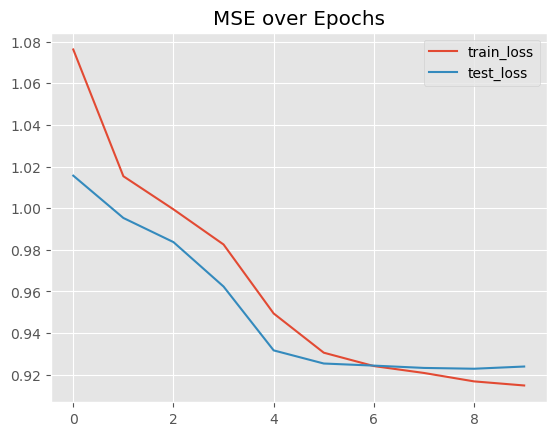

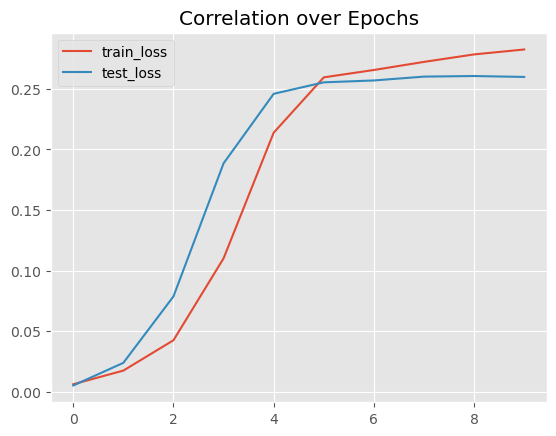

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:16<00:00,  1.69s/it]


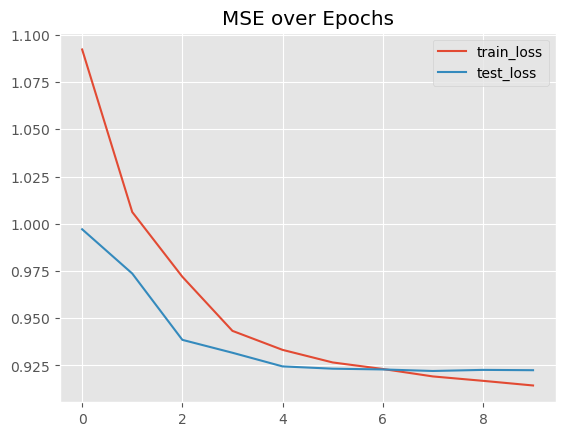

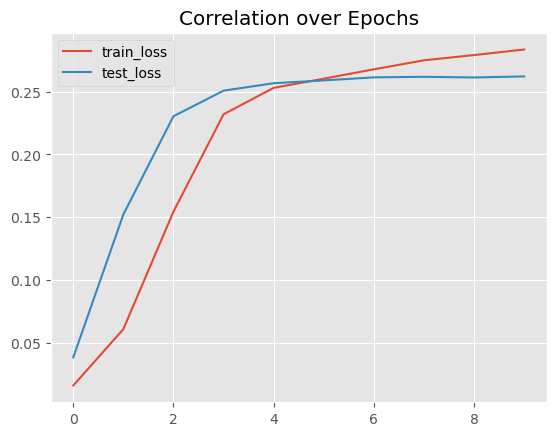

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:16<00:00,  1.66s/it]


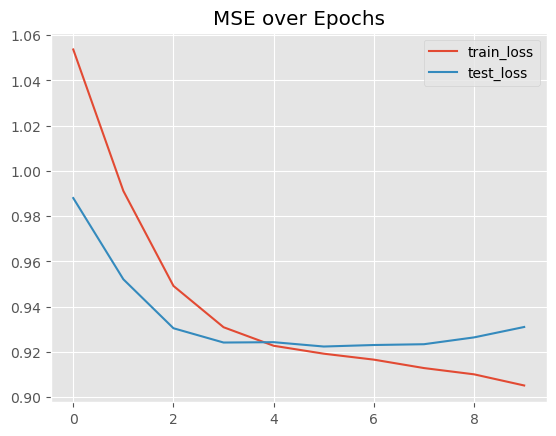

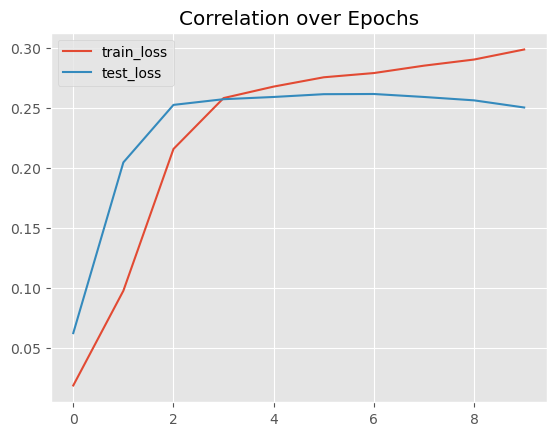

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:16<00:00,  1.66s/it]


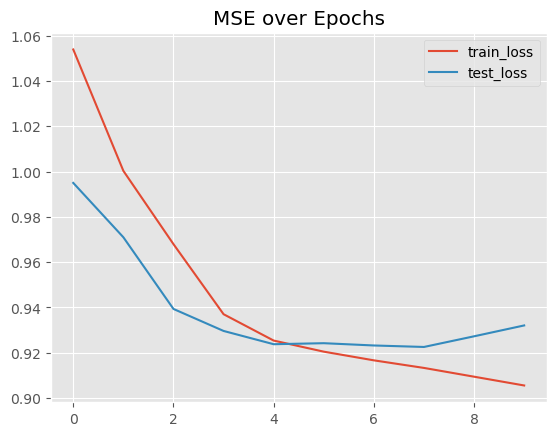

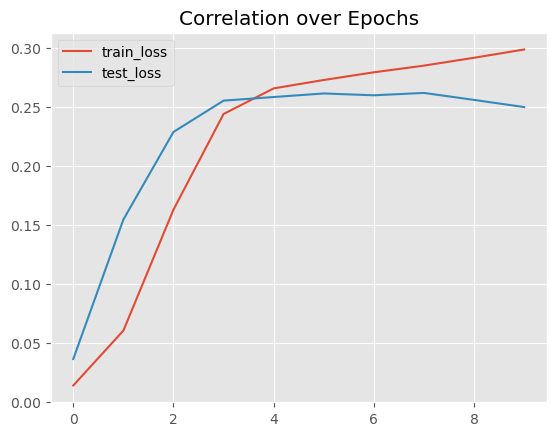

,true,optimal,shift,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse
optimal,0.300,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.300,1.000,nan,nan,nan,nan,nan,nan,nan
lasso,0.161,0.147,0.147,nan,nan,nan,nan,nan,nan
boosting,0.261,0.078,0.078,0.428,nan,nan,nan,nan,nan
mlp,0.298,0.098,0.098,0.506,0.786,nan,nan,nan,nan
full_attention,0.312,0.950,0.950,0.146,0.082,0.103,nan,nan,nan
deterministic_sparse,0.313,0.951,0.951,0.140,0.081,0.101,0.933,nan,nan
top_k_sparse,0.332,0.917,0.917,0.138,0.081,0.103,0.905,0.906,nan
max_sparse,0.331,0.909,0.909,0.144,0.087,0.109,0.900,0.903,0.880


,true,optimal,shift,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse
optimal,0.290,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.290,1.000,nan,nan,nan,nan,nan,nan,nan
lasso,0.033,0.122,0.122,nan,nan,nan,nan,nan,nan
boosting,0.014,0.011,0.011,0.140,nan,nan,nan,nan,nan
mlp,0.023,0.081,0.081,0.429,0.138,nan,nan,nan,nan
full_attention,0.277,0.952,0.952,0.121,0.013,0.081,nan,nan,nan
deterministic_sparse,0.277,0.950,0.950,0.109,0.008,0.078,0.932,nan,nan
top_k_sparse,0.264,0.920,0.920,0.115,0.014,0.080,0.908,0.909,nan
max_sparse,0.265,0.909,0.909,0.110,0.011,0.077,0.901,0.900,0.881


In [75]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.1]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  # Use L1 loss for sparse model
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=10)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

Full attention matrix FIRST layer

In [73]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.643,0.357,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.537,0.410,0.053,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.426,0.411,0.066,0.097,0.000,0.000,0.000,0.000,0.000,0.000
4,0.121,0.128,0.136,0.332,0.283,0.000,0.000,0.000,0.000,0.000
5,0.099,0.085,0.064,0.206,0.339,0.206,0.000,0.000,0.000,0.000
6,0.133,0.139,0.166,0.163,0.105,0.162,0.133,0.000,0.000,0.000
7,0.131,0.084,0.061,0.164,0.104,0.140,0.199,0.117,0.000,0.000
8,0.140,0.136,0.040,0.083,0.082,0.102,0.121,0.232,0.063,0.000
9,0.116,0.103,0.037,0.081,0.091,0.093,0.110,0.244,0.059,0.067


Full attention matrix SECOND layer

In [74]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[2].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.654,0.346,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.443,0.386,0.172,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.310,0.189,0.327,0.174,0.000,0.000,0.000,0.000,0.000,0.000
4,0.225,0.118,0.226,0.246,0.185,0.000,0.000,0.000,0.000,0.000
5,0.156,0.105,0.133,0.128,0.180,0.298,0.000,0.000,0.000,0.000
6,0.141,0.116,0.193,0.078,0.165,0.204,0.103,0.000,0.000,0.000
7,0.123,0.076,0.125,0.120,0.116,0.182,0.168,0.089,0.000,0.000
8,0.131,0.045,0.074,0.090,0.111,0.207,0.093,0.087,0.162,0.000
9,0.095,0.076,0.065,0.075,0.082,0.143,0.099,0.108,0.158,0.101


Sparsity matrix with the max proba algorithm FIRST layer

In [37]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.416,0.584,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.456,0.544,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.441,0.559,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.468,0.532,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.499,0.501,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.498,0.502,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.502,0.498,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.609,0.391,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.560,0.440


Sparsity matrix with the max proba algorithm SECOND layer

In [39]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[2].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.525,0.475,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.497,0.503,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.547,0.453,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.571,0.429,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.495,0.505,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.498,0.502,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.504,0.496,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.608,0.392,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.590,0.410


In [51]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


records_train = []
records_test  = [] 

for k in range(10):
    records_train.append({})
    records_test.append({})
    
    @dataclass
    class Config:
        T: int = 3000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device)
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20, plot=False)
        
        comp = benchmark_comparison.Comparator(models=[models_torch[k]], model_names=[k])

        
        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        train_corr = corr_train.loc[k, "optimal"]
        test_corr  = corr_test.loc[k, "optimal"]

        records_train[-1][k + '_train_corr'] = train_corr
        records_test[-1][k + '_test_corr'] = test_corr
        
    
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:26<00:00,  1.34s/it]


,true,optimal,shift,full_attention,deterministic_sparse,top_k_sparse
optimal,0.036,nan,nan,nan,nan,nan
shift,0.036,1.000,nan,nan,nan,nan
full_attention,0.328,0.103,0.103,nan,nan,nan
deterministic_sparse,0.311,0.200,0.200,0.328,nan,nan
top_k_sparse,0.371,0.166,0.166,0.300,0.350,nan
max_sparse,0.354,0.201,0.201,0.312,0.359,0.355


,true,optimal,shift,full_attention,deterministic_sparse,top_k_sparse
optimal,0.038,nan,nan,nan,nan,nan
shift,0.038,1.000,nan,nan,nan,nan
full_attention,0.001,0.111,0.111,nan,nan,nan
deterministic_sparse,-0.017,0.219,0.219,0.282,nan,nan
top_k_sparse,0.010,0.178,0.178,0.225,0.269,nan
max_sparse,-0.001,0.211,0.211,0.240,0.292,0.284


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:27<00:00,  1.35s/it]


,true,optimal,shift,full_attention,deterministic_sparse,top_k_sparse
optimal,0.037,nan,nan,nan,nan,nan
shift,0.037,1.000,nan,nan,nan,nan
full_attention,0.381,0.141,0.141,nan,nan,nan
deterministic_sparse,0.338,0.175,0.175,0.289,nan,nan
top_k_sparse,0.385,0.202,0.202,0.321,0.326,nan
max_sparse,0.430,0.150,0.150,0.346,0.314,0.345


...

,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse
optimal,0.031,nan,nan,nan,nan,nan,nan
shift,0.031,1.000,nan,nan,nan,nan,nan
lasso,0.023,-0.004,-0.004,nan,nan,nan,nan
full_attention,0.339,0.054,0.054,0.059,nan,nan,nan
deterministic_sparse,0.473,0.126,0.126,0.074,0.339,nan,nan
top_k_sparse,0.439,0.133,0.133,0.063,0.329,0.380,nan
max_sparse,0.388,0.120,0.120,0.082,0.313,0.361,0.346


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse
optimal,0.024,nan,nan,nan,nan,nan,nan
shift,0.024,1.000,nan,nan,nan,nan,nan
lasso,-0.013,0.000,0.000,nan,nan,nan,nan
full_attention,0.006,0.067,0.067,0.069,nan,nan,nan
deterministic_sparse,-0.005,0.129,0.129,0.074,0.244,nan,nan
top_k_sparse,0.019,0.155,0.155,0.072,0.208,0.233,nan
max_sparse,0.011,0.130,0.130,0.091,0.228,0.236,0.227


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:26<00:00,  1.32s/it]


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse
optimal,0.036,nan,nan,nan,nan,nan,nan
shift,0.036,1.000,nan,nan,nan,nan,nan
lasso,0.013,0.003,0.003,nan,nan,nan,nan
full_attention,0.351,0.142,0.142,0.060,nan,nan,nan
deterministic_sparse,0.391,0.162,0.162,0.065,0.352,nan,nan
top_k_sparse,0.326,0.203,0.203,0.064,0.358,0.374,nan
max_sparse,0.399,0.151,0.151,0.049,0.335,0.363,0.345


,true,optimal,shift,lasso,full_attention,deterministic_sparse,top_k_sparse
optimal,0.039,nan,nan,nan,nan,nan,nan
shift,0.039,1.000,nan,nan,nan,nan,nan
lasso,-0.002,0.011,0.011,nan,nan,nan,nan
full_attention,0.011,0.139,0.139,0.039,nan,nan,nan
deterministic_sparse,0.001,0.146,0.146,0.067,0.249,nan,nan
top_k_sparse,-0.012,0.225,0.225,0.089,0.298,0.305,nan
max_sparse,0.009,0.146,0.146,0.068,0.248,0.256,0.285


In [52]:
table_train = pd.DataFrame(records_train)
table_test  = pd.DataFrame(records_test)

In [53]:
display(pd.concat([table_test.quantile([0.1, 0.9]), table_test.aggregate(['min', 'max', 'mean', 'std'])]).T.style.background_gradient().format(precision=4))

,0.100000,0.900000,min,max,mean,std
full_attention_test_corr,0.0610,0.1525,0.0597,0.1839,0.1109,0.0428
deterministic_sparse_test_corr,0.1124,0.2178,0.1076,0.2510,0.1540,0.0466
top_k_sparse_test_corr,0.1027,0.2151,0.0870,0.2282,0.1631,0.0447
max_sparse_test_corr,0.1268,0.2180,0.1256,0.2194,0.1577,0.0345


In [54]:
display(pd.concat([table_train.quantile([0.1, 0.9]), table_train.aggregate(['min', 'max', 'mean', 'std'])]).T.style.background_gradient().format(precision=4))

,0.100000,0.900000,min,max,mean,std
full_attention_train_corr,0.0593,0.1457,0.0537,0.1899,0.1082,0.0443
deterministic_sparse_train_corr,0.1142,0.2051,0.1133,0.2509,0.1545,0.0438
top_k_sparse_train_corr,0.1007,0.2020,0.0940,0.2036,0.1552,0.0408
max_sparse_train_corr,0.1191,0.2045,0.1145,0.2160,0.1525,0.0332


## Cross-sectionnal study

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:23<00:00,  1.17s/it]


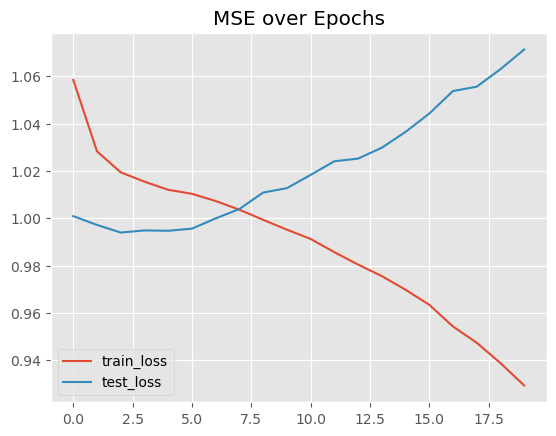

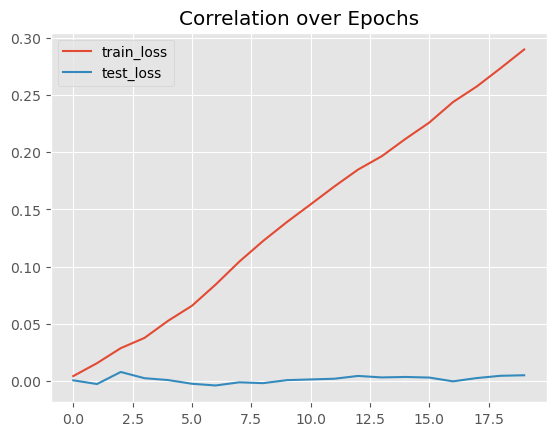

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.09it/s]


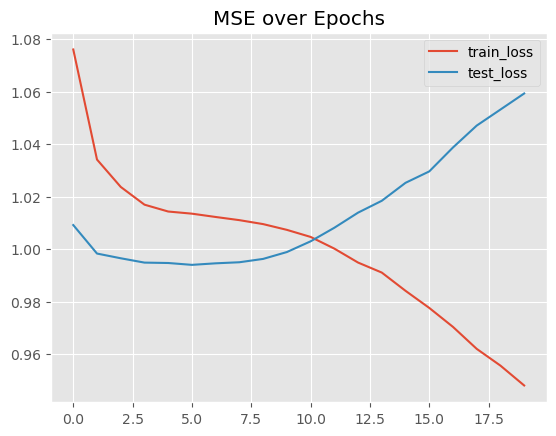

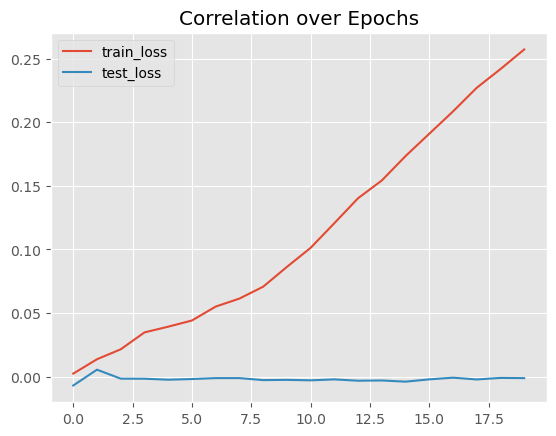

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.10it/s]


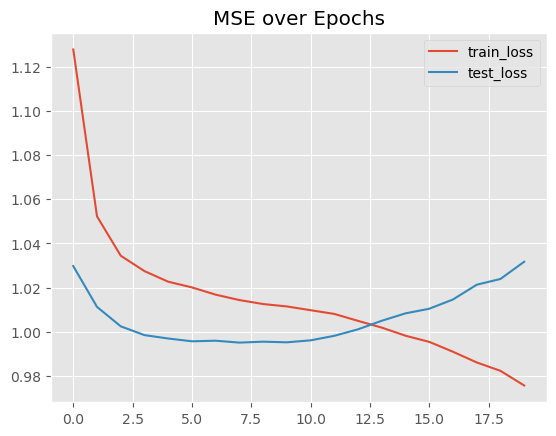

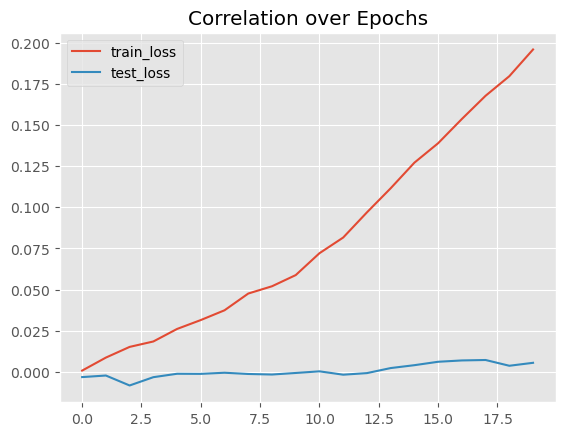

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:17<00:00,  1.13it/s]


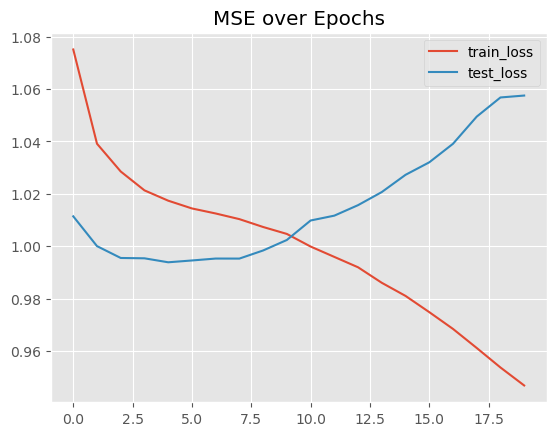

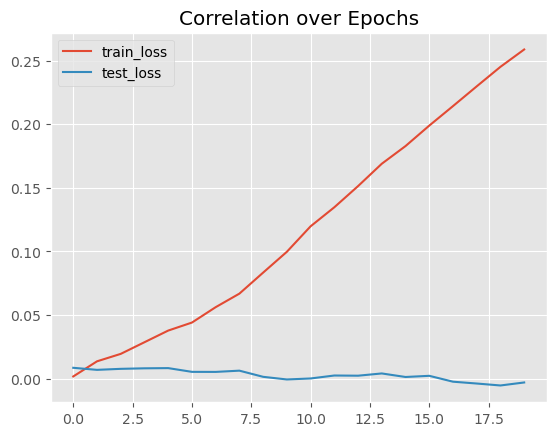

,true,optimal,cs,lasso,boosting,full_attention,deterministic_sparse,top_k_sparse
optimal,0.022,nan,nan,nan,nan,nan,nan,nan
cs,0.022,1.000,nan,nan,nan,nan,nan,nan
lasso,0.156,0.014,0.014,nan,nan,nan,nan,nan
boosting,0.256,0.015,0.015,0.408,nan,nan,nan,nan
full_attention,0.337,0.026,0.026,0.092,0.115,nan,nan,nan
deterministic_sparse,0.300,0.003,0.003,0.102,0.117,0.348,nan,nan
top_k_sparse,0.238,0.056,0.056,0.058,0.074,0.290,0.319,nan
max_sparse,0.304,0.053,0.053,0.084,0.110,0.352,0.345,0.311


,true,optimal,cs,lasso,boosting,full_attention,deterministic_sparse,top_k_sparse
optimal,0.035,nan,nan,nan,nan,nan,nan,nan
cs,0.035,1.000,nan,nan,nan,nan,nan,nan
lasso,-0.006,-0.001,-0.001,nan,nan,nan,nan,nan
boosting,-0.001,0.013,0.013,0.127,nan,nan,nan,nan
full_attention,0.004,0.029,0.029,0.030,0.002,nan,nan,nan
deterministic_sparse,0.002,0.010,0.010,0.054,0.007,0.292,nan,nan
top_k_sparse,0.011,0.052,0.052,0.028,-0.004,0.243,0.270,nan
max_sparse,-0.000,0.046,0.046,0.014,-0.003,0.295,0.286,0.263


In [45]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.01]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 1.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  # Use L1 loss for sparse model
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

## Conditional study

In [62]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmarkRolling(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:17<00:00,  1.11it/s]


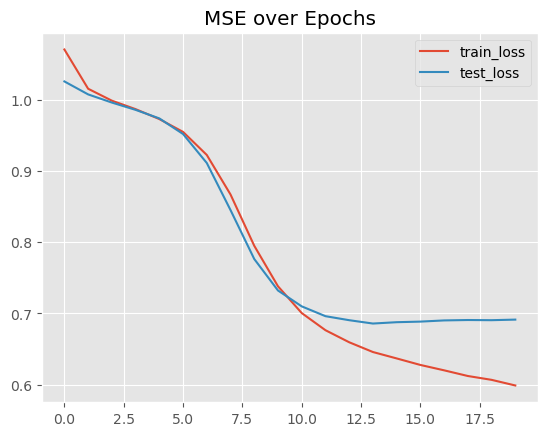

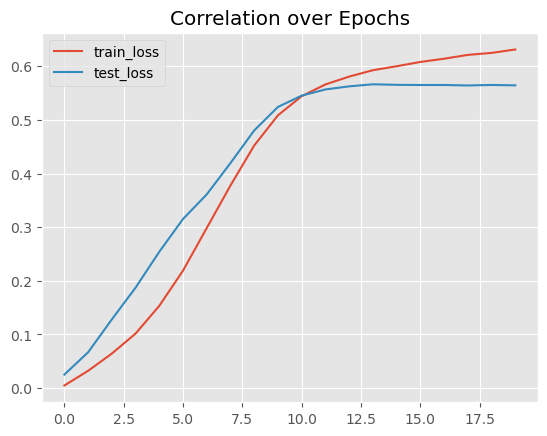

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:20<00:00,  1.01s/it]


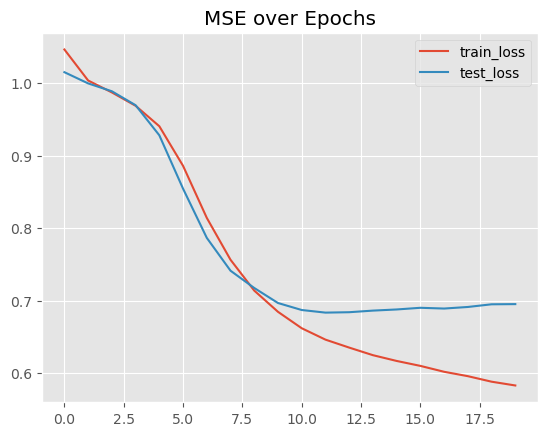

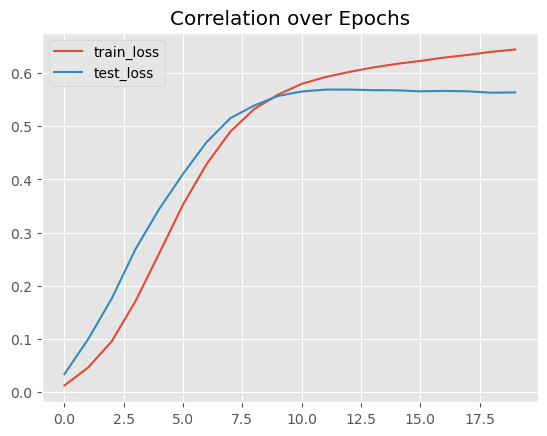

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:06<00:00,  2.86it/s]


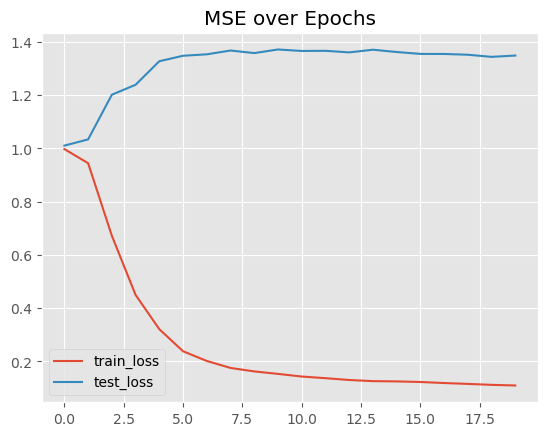

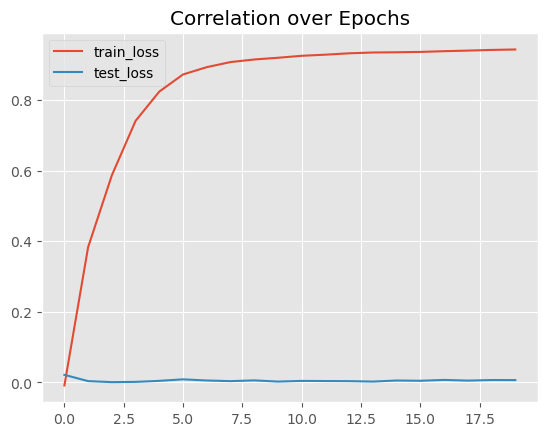

,true,optimal,conditional,lasso,boosting,mlp,full_attention,max_sparse
optimal,0.689,nan,nan,nan,nan,nan,nan,nan
conditional,0.689,1.000,nan,nan,nan,nan,nan,nan
lasso,0.159,0.113,0.113,nan,nan,nan,nan,nan
boosting,0.263,0.186,0.186,0.428,nan,nan,nan,nan
mlp,0.296,0.210,0.210,0.497,0.775,nan,nan,nan
full_attention,0.666,0.845,0.845,0.119,0.183,0.211,nan,nan
max_sparse,0.682,0.849,0.849,0.126,0.191,0.218,0.912,nan
MLP,0.983,0.676,0.676,0.152,0.251,0.280,0.654,0.670


,true,optimal,conditional,lasso,boosting,mlp,full_attention,max_sparse
optimal,0.691,nan,nan,nan,nan,nan,nan,nan
conditional,0.691,1.000,nan,nan,nan,nan,nan,nan
lasso,0.001,0.007,0.007,nan,nan,nan,nan,nan
boosting,0.016,0.007,0.007,0.154,nan,nan,nan,nan
mlp,-0.005,-0.009,-0.009,0.411,0.168,nan,nan,nan
full_attention,0.566,0.816,0.816,0.012,0.002,-0.002,nan,nan
max_sparse,0.565,0.818,0.818,0.013,0.001,-0.006,0.898,nan
MLP,0.007,0.009,0.009,0.127,0.059,0.204,0.033,0.026


In [64]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.3]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 1.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }
    
    models_no_roll = {'MLP': models.GlobalMLP(Config.n_ts, Config.n_f, 10, dropout=0.3).to(device)}


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  # Use L1 loss for sparse model
        ) for k in models_torch
    }
    
    models_no_roll = {
        k: torch_benchmarks.TorchWrapper(
            models_no_roll[k], 
            optimizer=torch.optim.AdamW(models_no_roll[k].parameters(), lr=0.001),
            loss_fn=nn.MSELoss()  # Use L1 loss for sparse model
        ) for k in models_no_roll
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    z.get_dataloader(n_rolling=10, roll_y=False)
    for k in models_no_roll:
        models_no_roll[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch] + [models_no_roll[k] for k in models_no_roll], 
        model_names=[k for k in models_linear] + [k for k in models_torch] + [k for k in models_no_roll]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

In [58]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmark(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmark(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmark(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

In [61]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 2, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 2, device=device)


for c in [0.03]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 1.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 2, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 2, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }
    
    models_no_roll = {'MLP': models.GlobalMLP(Config.n_ts, Config.n_f, 2, dropout=0.3).to(device)}


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss()  # Use L1 loss for sparse model
        ) for k in models_torch
    }
    
    models_no_roll = {
        k: torch_benchmarks.TorchWrapper(
            models_no_roll[k], 
            optimizer=torch.optim.AdamW(models_no_roll[k].parameters(), lr=0.001),
            loss_fn=nn.MSELoss()  # Use L1 loss for sparse model
        ) for k in models_no_roll
    }

    
    z.get_dataloader(n_rolling=2, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    z.get_dataloader(n_rolling=2, roll_y=False)
    for k in models_no_roll:
        models_no_roll[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch] + [models_no_roll[k] for k in models_no_roll], 
        model_names=[k for k in models_linear] + [k for k in models_torch] + [k for k in models_no_roll]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

 50%|██████████████████████████████████████████████████████▌                                                      | 10/20 [00:04<00:04,  2.40it/s]


KeyboardInterrupt: 